Business problem: Allocate marketing resources more efficiently by targeting customers based on purchasing power.
Retail businesses care about:
Conversion rate
Average order value

Lifetime value (LTV)
Because positive rate = 6%, this is imbalanced.

Business implication:
High-income group is small.
Precision matters.
False positives waste premium marketing spend.
So evaluation should focus on:
Precision at top K
PR-AUC
Lift charts
Not accuracy.
ROI of campaigns
ML problem: 

Identify high-spending potential customers and treat them differently from low-spending potential customers.

What Makes It Valuable
If the model works:
Instead of blasting campaigns to everyone:
They can target top 20% predicted earners
Increase response rate
Increase average basket size
Reduce wasted advertising spend
Even a small lift in precision can generate large financial gains at scale.
Income prediction is a means, not the end.

The end is:
Marketing segmentation
Resource optimization
Revenue lift

reading column names file
reading the comma-separated data
cleaning ? / whitespace / trailing periods
basic EDA (missingness, target split, numeric summaries, top categories, quick feature associations)
a baseline classifier (logistic regression) with a clean preprocessing pipeline
a segmentation model (k-means on encoded features) + how segments differ

In [70]:
# 1. load & clean

import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = Path("census-bureau.data")
COLS_PATH = Path("census-bureau.columns")

def load_columns(cols_path: Path) -> list[str]:
    # .columns looks like one name per line
    cols = pd.read_csv(cols_path, header=None, names=["col"])["col"].tolist()
    cols = [c.strip() for c in cols if str(c).strip() != ""]
    return cols

def load_data(data_path: Path, cols: list[str]) -> pd.DataFrame:
    # Data is comma-separated; lots of spaces after commas
    df = pd.read_csv(
        data_path,
        header=None,
        names=cols,
        sep=",",
        engine="python",
        skipinitialspace=True
    )

    # Standardize strings
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        df[c] = (
            df[c].astype(str)
                 .str.strip()
                 .replace({"?": np.nan, "nan": np.nan})
        )

    # Many targets are like "- 50000." or "50000+."
    # Strip trailing periods from all object columns
    for c in obj_cols:
        df[c] = df[c].str.replace(r"\.$", "", regex=True)

    return df

cols = load_columns(COLS_PATH)
df = load_data(DATA_PATH, cols)

print("shape:", df.shape)
df.head()


shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000


In [71]:
# 2. identify target with premise checks:
target_col = df.columns[-1]
print("target_col:", target_col)
print(df[target_col].value_counts(dropna=False))

mapping = {
    "- 50000": 0,
    "50000+": 1
}

df["y"] = df["label"].map(mapping).astype(int)
print(df["y"].value_counts(dropna=False))
print(df["y"].value_counts(normalize=True))



target_col: label
label
- 50000    187141
50000+      12382
Name: count, dtype: int64
y
0    187141
1     12382
Name: count, dtype: int64
y
0    0.937942
1    0.062058
Name: proportion, dtype: float64


In [72]:
# Missingness
missing = df.isna().mean().sort_values(ascending=False)
print("Top missing columns:\n", missing.head(15))

# Split columns
feature_cols = [c for c in df.columns if c not in [target_col, "y"]]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("num:", len(num_cols), "cat:", len(cat_cols))

# Target rate
y_rate = df["y"].mean()
print("Positive rate (income > 50k):", float(y_rate))




Top missing columns:
 migration code-change in msa                  0.499672
migration code-change in reg                  0.499672
migration code-move within reg                0.499672
migration prev res in sunbelt                 0.499672
country of birth father                       0.033645
country of birth mother                       0.030668
country of birth self                         0.017006
hispanic origin                               0.004380
state of previous residence                   0.003548
citizenship                                   0.000000
own business or self employed                 0.000000
detailed household and family stat            0.000000
fill inc questionnaire for veteran's admin    0.000000
family members under 18                       0.000000
num persons worked for employer               0.000000
dtype: float64
num: 13 cat: 28
Positive rate (income > 50k): 0.06205800834991455


In [73]:
migration_cols = [
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt"
]

for c in migration_cols:
    print(c)
    print(pd.crosstab(df[c].isna(), df["y"], normalize="index"))


migration code-change in msa
y                                    0         1
migration code-change in msa                    
False                         0.941509  0.058491
True                          0.934370  0.065630
migration code-change in reg
y                                    0         1
migration code-change in reg                    
False                         0.941509  0.058491
True                          0.934370  0.065630
migration code-move within reg
y                                      0         1
migration code-move within reg                    
False                           0.941509  0.058491
True                            0.934370  0.065630
migration prev res in sunbelt
y                                     0         1
migration prev res in sunbelt                    
False                          0.941509  0.058491
True                           0.934370  0.065630


class imbalance is significant. 
Migration related data have near 50% missing values. They are unlikely to drive income strongly and will introduce noise.
-migration code-change in msa
-migration code-change in reg
-migration code-move within reg
-migration prev res in sunbelt
Therefore I will drop these.

Baseline positive rate ≈ 6.21%
based on the output:
Missing group → 5.85%
Non-missing group → 6.56%
Difference ≈ 0.7% absolute
Relative lift ≈ 12%
This is small.
Given:
50% missing
Likely correlated with other geography variables
Adds dimensional complexity
Drop all four migration variables.
They do not provide strong standalone separation.

for other missing data:
Categorical → fill with "Missing"
Numeric → median

In [74]:
TOP_K = 10
for c in cat_cols[:10]:  # first 10, adjust as needed
    vc = df[c].value_counts(dropna=False).head(TOP_K)
    print(f"\n{c} (top {TOP_K})")
    print(vc)


class of worker (top 10)
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

education (top 10)
education
High school graduate                      48407
Children                                  47422
Some college but no degree                27820
Bachelors degree(BA AB BS)                19865
7th and 8th grade                          8007
10th grade                                 7557
11th grade                                 6876
Masters degree(MA MS MEng MEd MSW MBA)     6541
9th grade                                  6230
Associates degree-occup /vocational        5358
Name: count, dtype: int64

enroll in edu inst last wk

Investigate “Not in universe” categories
Many categorical variables have:
* "Not in universe"
* "Children"
* Similar administrative categories
These often correspond to:
* minors
* unemployed
* not applicable
You should:
* Keep them for now
* Later test whether they act as strong signals
Do not drop yet.


In [75]:
# find variables actually separate income groups:

# education vs income 
pd.crosstab(df["education"], df["y"], normalize="index").sort_values(1, ascending=False).head(15)



y,0,1
education,,
Prof school degree (MD DDS DVM LLB JD),0.459565,0.540435
Doctorate degree(PhD EdD),0.479810,0.520190
Masters degree(MA MS MEng MEd MSW MBA),0.688427,0.311573
Bachelors degree(BA AB BS),0.802920,0.197080
Associates degree-academic program,0.905570,0.094430
Associates degree-occup /vocational,0.922919,0.077081
Some college but no degree,0.935766,0.064234
High school graduate,0.961183,0.038817
12th grade no diploma,0.984008,0.015992


In [76]:
# occupation vs. income 
pd.crosstab(df["major occupation code"], df["y"], normalize="index").sort_values(1, ascending=False).head(15)



y,0,1
major occupation code,,
Executive admin and managerial,0.712445,0.287555
Professional specialty,0.750717,0.249283
Armed Forces,0.777778,0.222222
Protective services,0.844070,0.155930
Sales,0.870661,0.129339
Technicians and related support,0.880384,0.119616
Precision production craft & repair,0.909203,0.090797
Transportation and material moving,0.935572,0.064428
Farming forestry and fishing,0.949142,0.050858


      count       mean        std   min   25%   50%   75%   max
y                                                              
0  187141.0  33.715316  22.620236   0.0  14.0  31.0  49.0  90.0
1   12382.0  46.266193  11.830906  16.0  38.0  45.0  53.0  90.0


<Axes: title={'center': 'age'}, xlabel='y'>

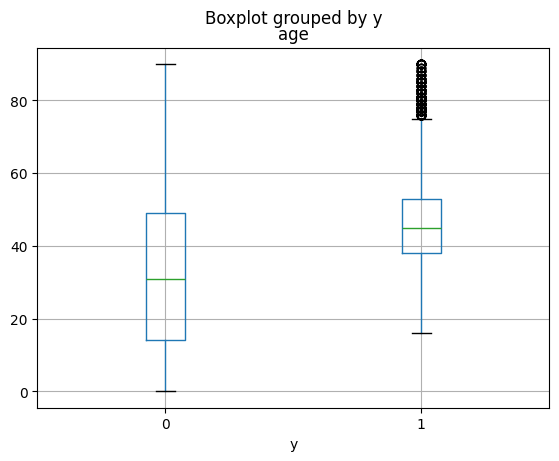

In [77]:
# age distribution
print(df.groupby("y")["age"].describe())
df.boxplot(column="age", by="y")



In [78]:
# distribution of year
df["year"].value_counts()

year
94    99827
95    99696
Name: count, dtype: int64

correlation analysis 
Strong Signals Identified
Now look at what really separates income.
Education
Massive gradient:
* Prof degree → 54%
* PhD → 52%
* Masters → 31%
* Bachelor → 19%
* High school → 3.8%
* Below HS → <1%
This is extremely strong signal.
Keep education. Consider ordinal encoding (education has natural order).

Major Occupation
Very strong separation:
* Executive → 28.8%
* Professional → 24.9%
* Clerical → 3%
* Service → 1%
Also strong signal.
Keep major occupation code. Drop detailed occupation for now (high cardinality).

Age
Mean age:
* Low income: 33.7
* High income: 46.3
Very strong separation.
Keep age. Consider non-linear relationship (tree model handles naturally).

### 
remove leakage - since we're investigating real demographic marketing, we're going to remove high leakge data
eg:
wage per hour
capital gains
capital losses
dividends

Model A: No financial variables
Model B: With financial variables
###



In [79]:
drop_cols = [
    "year",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "detailed industry recode",
    "detailed occupation recode",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",
    "weight"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


what to drop & why
1. year
* Survey year (1994 or 1995)
Why drop:
* It does not describe the individual.
* It reflects macroeconomic timing.
* It will not exist for future prospects in marketing.
* It risks learning year-specific income distribution rather than person-level signal.
If you include it, the model may partially learn:
“People surveyed in 1995 earned slightly more”
That is not a meaningful marketing feature.

2. Financial Variables 
wage per hour
capital gains
capital losses
dividends from stocks
These are problematic because they are either:
* Direct income components
* Strong income proxies
Your target is:
Income > 50K
If you include wage, capital gains, or dividends, the model is effectively seeing income.
This creates target leakage.
Leakage means: The model learns something that would not be available at prediction time.
From a retail perspective:
Would your client realistically know:
* Capital gains?
* Dividends?
* Hourly wage?
Almost certainly not.
So keeping them gives artificially high accuracy but no real-world usability.

3. Detailed Occupation / Industry Recode 

detailed industry recode
detailed occupation recode
Problems:
* Very high cardinality
* Many rare categories
* Increases dimensionality significantly
* Causes unstable one-hot encoding
You already have:

major industry code
major occupation code
These are aggregated versions with strong signal.
Start with major codes.We can revisit detailed codes later if performance is insufficient.

4. Migration Variables
Missing group → 5.85% Non-missing group → 6.56%
Difference ≈ 0.7%
That is weak.
Additionally:
* 50% missing
* Adds complexity
* Hard to interpret in marketing context
For retail segmentation, migration is unlikely to be a primary income driver.
So cost > benefit.

5. survey weight
Survey weight is used to:
* Estimate population-level proportions
It is not an individual characteristic.
Including it:
* Does not help prediction
* May introduce bias
Unless you are building weighted models for population inference, drop it.


In [80]:
feature_cols = [c for c in df.columns if c not in [target_col, "y"]]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print(feature_cols)
print(num_cols)
print(cat_cols)

['age', 'class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked in year']
['age', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year']
['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic 

In [81]:
for col in num_cols:
    print("\n", col)
    print(df.groupby("y")[col].mean())



 age
y
0    33.715316
1    46.266193
Name: age, dtype: float64

 num persons worked for employer
y
0    1.820707
1    4.003715
Name: num persons worked for employer, dtype: float64

 own business or self employed
y
0    0.169674
1    0.262559
Name: own business or self employed, dtype: float64

 veterans benefits
y
0    1.483967
1    1.981344
Name: veterans benefits, dtype: float64

 weeks worked in year
y
0    21.527762
1    48.069617
Name: weeks worked in year, dtype: float64


In [82]:
pd.crosstab(df[col], df["y"], normalize="index").sort_values(1, ascending=False)


y,0,1
weeks worked in year,,
52,0.851992,0.148008
51,0.890110,0.109890
50,0.892795,0.107205
49,0.893910,0.106090
46,0.911017,0.088983
48,0.913068,0.086932
41,0.920455,0.079545
37,0.934959,0.065041
29,0.936508,0.063492


52 weeks → 14.8%
50 weeks → 10.7%
45 weeks → 5.7%
30 weeks → 3.0%
0 weeks → 0.6%
shows nonlinear pattern, so logistic regression with a linear term may underfit this pattern.

In [83]:
# consider binning for linear regression while keep the origional value for tree models since they learn these patterns automatically 
def bin_weeks(x):
    if x == 0:
        return "0"
    elif x < 26:
        return "1-25"
    elif x < 48:
        return "26-47"
    else:
        return "48-52"


In [84]:
# This computes each categorical column’s max lift over baseline, plus coverage and number of levels. It’s a fast way to prioritize.

import numpy as np
import pandas as pd

baseline = df["y"].mean()

def cat_signal_summary(df, cat_cols, y_col="y", min_count=200):
    rows = []
    for c in cat_cols:
        s = df[c].astype("object").fillna("Missing")
        tmp = pd.DataFrame({"x": s, "y": df[y_col]})
        vc = tmp["x"].value_counts(dropna=False)
        # only evaluate levels with enough support
        keep_levels = vc[vc >= min_count].index
        grp = tmp[tmp["x"].isin(keep_levels)].groupby("x")["y"].agg(["mean", "count"])
        if grp.empty:
            continue

        max_rate = grp["mean"].max()
        min_rate = grp["mean"].min()
        max_lift = max_rate / baseline if baseline > 0 else np.nan
        min_lift = min_rate / baseline if baseline > 0 else np.nan

        rows.append({
            "feature": c,
            "n_levels": int(tmp["x"].nunique()),
            "missing_rate": float(df[c].isna().mean()),
            "coverage_ge_min": float(grp["count"].sum() / len(df)),
            "max_rate": float(max_rate),
            "min_rate": float(min_rate),
            "max_lift_over_baseline": float(max_lift),
            "min_lift_over_baseline": float(min_lift),
        })

    out = pd.DataFrame(rows).sort_values("max_lift_over_baseline", ascending=False)
    return out

cat_summary = cat_signal_summary(df, cat_cols, y_col="y", min_count=200)
cat_summary.head(20)


,feature,n_levels,missing_rate,coverage_ge_min,max_rate,min_rate,max_lift_over_baseline,min_lift_over_baseline
1,education,17,0.000000,1.000000,0.540435,0.000000,8.708546,0.000000
0,class of worker,9,0.000000,0.999173,0.347320,0.004556,5.596700,0.073412
5,major occupation code,15,0.000000,0.999820,0.287555,0.002564,4.633649,0.041318
4,major industry code,24,0.000000,0.998882,0.259325,0.005291,4.178752,0.085259
21,country of birth self,43,0.017006,0.991244,0.174020,0.008721,2.804144,0.140529
15,detailed household and family stat,38,0.000000,0.996632,0.147423,0.000000,2.375574,0.000000
20,country of birth mother,43,0.030668,0.993715,0.139415,0.006757,2.246524,0.108878
19,country of birth father,43,0.033645,0.992507,0.136207,0.004494,2.194832,0.072422
9,member of a labor union,3,0.000000,1.000000,0.135974,0.056234,2.191073,0.906158
23,fill inc questionnaire for veteran's admin,3,0.000000,1.000000,0.134965,0.040921,2.174828,0.659395


In [85]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder

def chi2_rank(df, cat_cols, y_col="y", min_count=100):
    X = df[cat_cols].copy()
    for c in cat_cols:
        X[c] = X[c].astype("object").fillna("Missing")

        # collapse rare levels to reduce noise before chi2
        vc = X[c].value_counts()
        rare = vc[vc < min_count].index
        X.loc[X[c].isin(rare), c] = "Other"

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_ohe = ohe.fit_transform(X)
    y = df[y_col].astype(int).values

    chi2_vals, pvals = chi2(X_ohe, y)

    # aggregate chi2 back to original feature using encoder feature names
    feat_names = ohe.get_feature_names_out(cat_cols)
    chi_df = pd.DataFrame({"ohe_feat": feat_names, "chi2": chi2_vals, "pval": pvals})
    chi_df["orig_feat"] = chi_df["ohe_feat"].str.split("_", n=1).str[0]
    agg = chi_df.groupby("orig_feat")["chi2"].sum().sort_values(ascending=False)
    return agg.reset_index().rename(columns={"orig_feat":"feature", "chi2":"chi2_sum"})

chi_rank = chi2_rank(df, cat_cols, y_col="y", min_count=100)
chi_rank.head(20)


,feature,chi2_sum
0,education,30322.049718
1,major occupation code,26765.882894
2,major industry code,15404.367654
3,class of worker,13542.953109
4,detailed household and family stat,11529.389364
5,tax filer stat,10484.359945
6,detailed household summary in household,10301.203726
7,marital stat,7794.867355
8,full or part time employment stat,5098.018910
9,family members under 18,5054.768316


detailed household variables rank high

But:
Hard to interpret
Less business intuitive
More noisy
education + occupation already dominate.

tax filer stat ranks high
But this is likely leakage / income-adjacent.


data leakage variables - cateogorical: 
tax filer stat → too income-adjacent
fill inc questionnaire for veteran's admin → administrative artifact

Tier 1 — Must Keep (Very Strong Signal)
These are extremely powerful predictors:
Feature	Max Lift
education	8.7x
class of worker	5.6x
major occupation code	4.6x
major industry code	4.2x
These are core economic variables.
Keep all four.
These alone likely get you strong PR-AUC.

Tier 2 — Strong But Consider Carefully
Feature	Max Lift
country of birth self	2.8x
detailed household and family stat	2.37x
country of birth mother	2.25x
country of birth father	2.19x
member of labor union	2.19x
fill inc questionnaire for veteran's admin	2.17x
full or part time employment stat	2.12x
tax filer stat	2.11x
Now we apply business reasoning.
Drop Immediately (Leakage / Administrative)
* tax filer stat → too income-adjacent
* fill inc questionnaire for veteran's admin → administrative artifact
These inflate performance but hurt deployability.

Country of birth variables
Strong lift, but:
* 43 levels
* Potential fairness / compliance issues
* Hard to justify in retail targeting
If this is a school assignment → optional If this is real business → likely exclude

Full or part time employment stat
This is useful and aligned with income logic.
But you already have:
* weeks worked (very strong)
Check redundancy:
If correlation high, choose one.
Often:
* Keep weeks worked
* Drop full/part

Labor union
Moderate lift. Low cardinality. Reasonable business justification.
Optional keep.

Tier 3 — Moderate
Feature	Max Lift
marital stat	1.84x
sex	1.64x
citizenship	1.59x
family members under 18	1.38x
Marital status is usually strong in income models.
Sex and citizenship may raise fairness considerations.
Family members under 18 → weaker but usable.

Tier 4 — Weak
Feature	Max Lift
state of previous residence	1.28x
race	1.19x
hispanic origin	1.10x
These are weak relative to others.
Unless performance gain is measurable, drop them.

Recommended Final Categorical Set (Balanced + Deployable)
Keep
* education
* class of worker
* major occupation code
* major industry code
* marital stat
* weeks_bin (your engineered variable)
Optional (if needed for lift):
* member of labor union

Recommended Drop
* tax filer stat
* fill inc questionnaire for veteran's admin
* country of birth *
* detailed household *
* state of previous residence
* hispanic origin
* race (optional — depends on fairness policy)
* citizenship (optional)


In [ ]:
# 1) Business-driven keep/drop lists (based on lift table)

# Tier 1 must keep
cat_keep_core = [
    "education",
    "class of worker",
    "major occupation code",
    "major industry code",
    "marital stat",
]

# Optional (keep only if you decide it is acceptable)
cat_optional = [
    "member of a labor union",
]

# Recommended drops (leakage / admin / weak / fairness-sensitive)
cat_drop = [
    "tax filer stat",
    "fill inc questionnaire for veteran's admin",
    "country of birth father",
    "country of birth mother",
    "country of birth self",
    "detailed household and family stat",
    "detailed household summary in household",
    "state of previous residence",
    "hispanic origin",
    "race",
    "citizenship",
]

# Keep numeric you decided (update as needed)
num_keep = [
    "age",
    "num persons worked for employer",
    "own business or self employed",
    "veterans benefits",   # optional; keep if you want
]

# Add engineered weeks bins (recommended) as categorical
def bin_weeks(x):
    if pd.isna(x): return "Missing"
    x = int(x)
    if x == 0: return "0"
    if x < 26: return "1-25"
    if x < 48: return "26-47"
    return "48-52"

df = df.copy()
df["weeks_bin"] = df["weeks worked in year"].apply(bin_weeks)

cat_keep = cat_keep_core + ["weeks_bin"] + cat_optional  # if you want union


# 2) Safety checks: ensure chosen cols exist and are categorical

cat_keep = [c for c in cat_keep if c in df.columns]
num_keep = [c for c in num_keep if c in df.columns]

print("Final cat_keep:", cat_keep)
print("Final num_keep:", num_keep)

# Optional: verify that dropped cols are indeed removed from candidate cat_cols
cat_cols_remaining = [c for c in cat_cols if c not in cat_drop]
print("cat cols remaining after drop list:", cat_cols_remaining)


# 3) Collapse rare categories + fill missing

def clean_categoricals(df, cols, rare_thresh=0.01):
    """
    rare_thresh: categories below this fraction become 'Other'
    """
    out = df.copy()
    for c in cols:
        out[c] = out[c].astype("object").fillna("Missing")
        freq = out[c].value_counts(normalize=True)
        rare_levels = freq[freq < rare_thresh].index
        out.loc[out[c].isin(rare_levels), c] = "Other"
    return out

df_clean = clean_categoricals(df, cat_keep, rare_thresh=0.01)



Final cat_keep: ['education', 'class of worker', 'major occupation code', 'major industry code', 'marital stat', 'weeks_bin', 'member of a labor union']
Final num_keep: ['age', 'num persons worked for employer', 'own business or self employed', 'veterans benefits']
cat cols remaining after drop list: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'region of previous residence', 'live in this house 1 year ago', 'family members under 18']


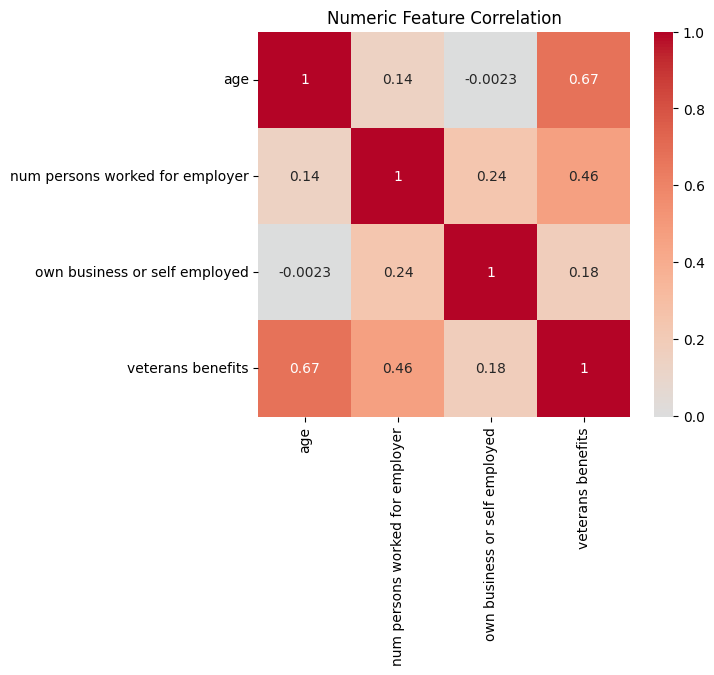

In [87]:
# numerical heatmap:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(df[num_keep].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation")
plt.show()



Model training - baseline 

In [88]:
# =========================
# 4) Encode + train baseline model (logistic regression)
# =========================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

X = df_clean[num_keep + cat_keep]
y = df_clean["y"].astype(int)

# --- Protocol B: hold out TEST once; use DEV for CV/tuning ---
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_keep),
        ("cat", categorical_tf, cat_keep)
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_dev, y_dev)

proba = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))


ROC-AUC: 0.9229182271972999
PR-AUC : 0.46591543989874074


In [89]:
import numpy as np

def precision_at_k(y_true, y_score, k_frac=0.10):
    k = int(np.ceil(len(y_true) * k_frac))
    idx = np.argsort(-y_score)[:k]
    return np.mean(y_true.iloc[idx])

def lift_at_k(y_true, y_score, k_frac=0.10):
    baseline = y_true.mean()
    return precision_at_k(y_true, y_score, k_frac) / baseline

p10 = precision_at_k(y_test.reset_index(drop=True), pd.Series(proba), 0.10)
l10 = lift_at_k(y_test.reset_index(drop=True), pd.Series(proba), 0.10)

print("Precision@Top10%:", p10)
print("Lift@Top10%:", l10)


Precision@Top10%: 0.39592382225192113
Lift@Top10%: 6.381046890779616


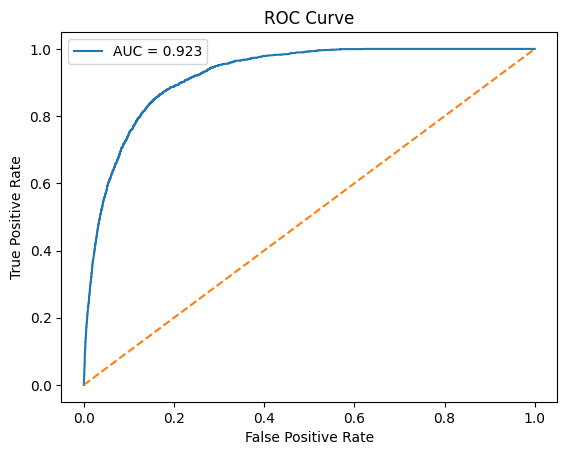

In [90]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


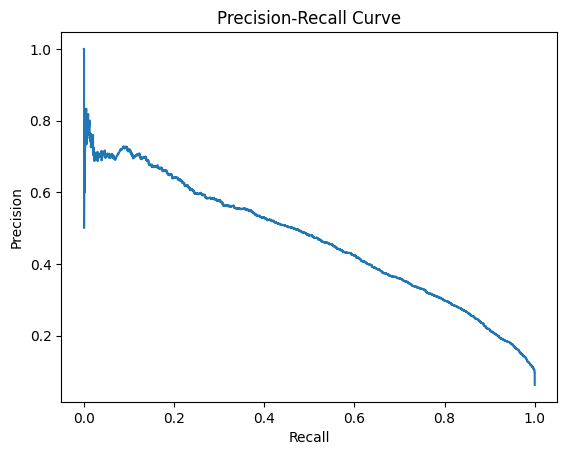

In [91]:

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


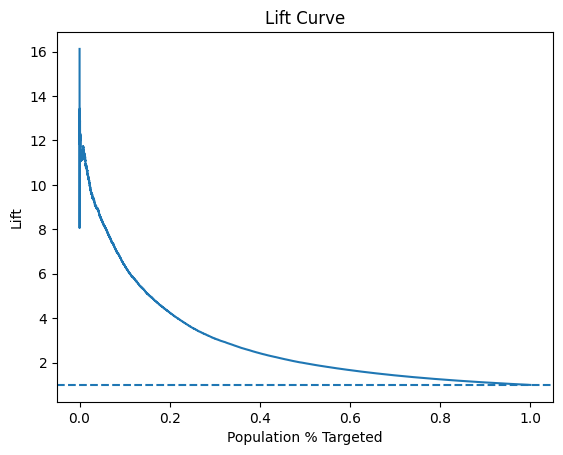

In [92]:
import numpy as np

def plot_lift(y_true, y_score):
    df_lift = pd.DataFrame({
        "y": y_true,
        "score": y_score
    }).sort_values("score", ascending=False)

    df_lift["cum_pos"] = df_lift["y"].cumsum()
    df_lift["population_pct"] = np.arange(1, len(df_lift)+1) / len(df_lift)
    df_lift["lift"] = df_lift["cum_pos"] / (df_lift["population_pct"] * df_lift["y"].sum())

    plt.figure()
    plt.plot(df_lift["population_pct"], df_lift["lift"])
    plt.axhline(1, linestyle="--")
    plt.xlabel("Population % Targeted")
    plt.ylabel("Lift")
    plt.title("Lift Curve")
    plt.show()

plot_lift(y_test.reset_index(drop=True), proba)


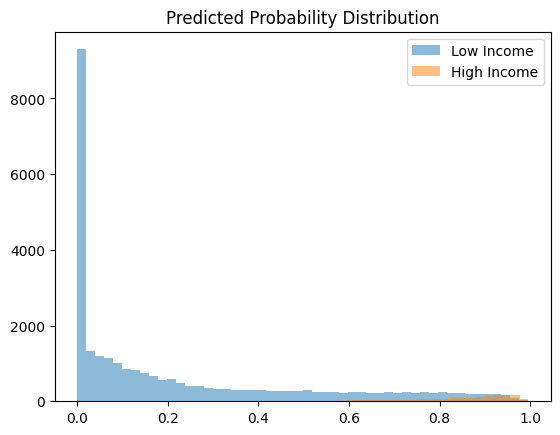

In [93]:
# Probability Distribution by Class
plt.figure()
plt.hist(proba[y_test==0], bins=50, alpha=0.5, label="Low Income")
plt.hist(proba[y_test==1], bins=50, alpha=0.5, label="High Income")
plt.legend()
plt.title("Predicted Probability Distribution")
plt.show()


In [94]:
# Feature Importance (Logistic Coefficients)
ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feature_names = (
    num_keep +
    list(ohe.get_feature_names_out(cat_keep))
)

coefs = model.named_steps["lr"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", key=abs, ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df.sort_values("odds_ratio", ascending=False).head(20)


,feature,coef,odds_ratio
16,education_Other,2.124491,8.368634
15,education_Masters degree(MA MS MEng MEd MSW MBA),2.114348,8.284186
12,education_Bachelors degree(BA AB BS),1.485929,4.419071
22,class of worker_Self-employed-incorporated,1.138770,3.122924
0,age,0.939985,2.559943
66,weeks_bin_48-52,0.847679,2.334223
27,major occupation code_Executive admin and mana...,0.832140,2.298232
10,education_Associates degree-academic program,0.698190,2.010112
35,major occupation code_Professional specialty,0.656707,1.928432
17,education_Some college but no degree,0.606997,1.834913


since we used OneHotEncoder.
For each categorical variable:
* One category is treated as the implicit baseline (reference)
* All other categories are compared against that baseline
So a negative coefficient does NOT mean:
“This feature reduces income”
It means:
“This category has lower odds of high income relative to the reference category.”

eg.education_Children 
This means:
* Compared to the baseline education category,
    * Children are much less likely to earn >50K
    * Masters are much more likely



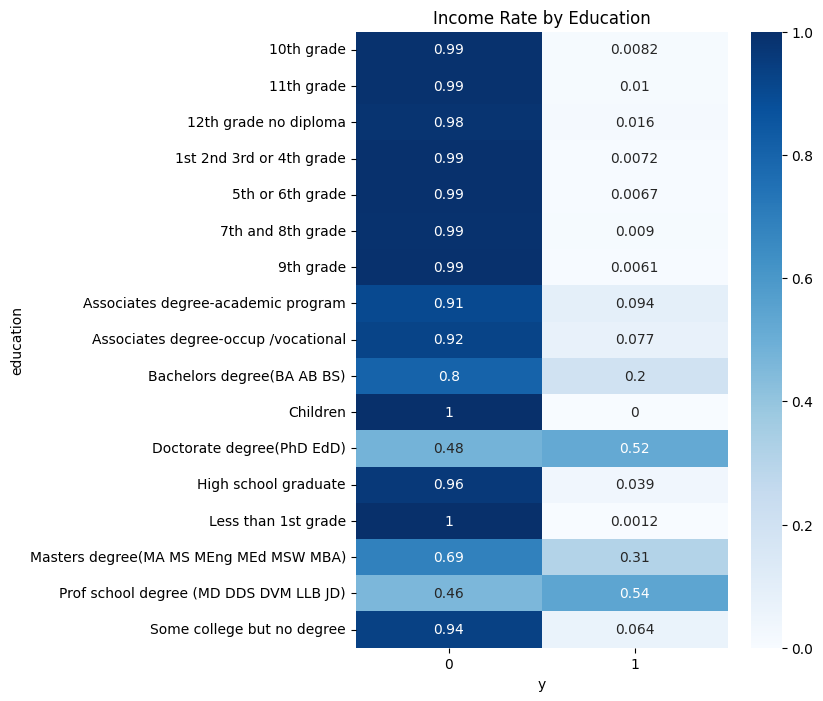

In [95]:
ct = pd.crosstab(df["education"], df["y"], normalize="index")

plt.figure(figsize=(6,8))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Income Rate by Education")
plt.show()


In [96]:
df_eval = pd.DataFrame({"y": y_test, "score": proba})
df_eval["decile"] = pd.qcut(df_eval["score"], 10, labels=False, duplicates="drop")

decile_summary = df_eval.groupby("decile")["y"].mean().sort_index(ascending=False)
print(decile_summary)


decile
9    0.395924
8    0.132063
7    0.045743
6    0.027397
5    0.011702
4    0.007350
3    0.000334
2    0.000000
1    0.000000
0    0.000000
Name: y, dtype: float64


interpretation: 
If we randomly target 10% of the population, only 6.2% would be high-income.
Using our baseline model, when targeting the top 10% highest predicted earners:
40% of them are actually high-income.
That is a 6.46× improvement over random targeting.

Translate Into Business ROI
Assume:
* 100,000 prospects
* Marketing budget allows targeting 10,000 people (10%)
Random targeting:
10,000 × 6.2% ≈ 620 high-income customers reached
Model targeting:
10,000 × 40.1% ≈ 4,010 high-income customers reached
That is:
+3,390 additional high-income prospects reached Using the same marketing budget.
This is substantial efficiency gain.

check for overfitting: use cv 

In [97]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(
    model, X_dev, y_dev,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

pr_scores = cross_val_score(
    model, X_dev, y_dev,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print("ROC-AUC CV mean:", roc_scores.mean())
print("ROC-AUC CV std :", roc_scores.std())

print("PR-AUC CV mean :", pr_scores.mean())
print("PR-AUC CV std  :", pr_scores.std())


ROC-AUC CV mean: 0.9181079472471385
ROC-AUC CV std : 0.0021483775330637246
PR-AUC CV mean : 0.4666916235644404
PR-AUC CV std  : 0.009828358049981013


In [98]:
# DEV performance (note: this is in-sample; CV below is the better check)
proba_dev = model.predict_proba(X_dev)[:, 1]

print("DEV ROC-AUC:", roc_auc_score(y_dev, proba_dev))
print("DEV PR-AUC :", average_precision_score(y_dev, proba_dev))


DEV ROC-AUC: 0.9187980632375896
DEV PR-AUC : 0.46811697247465656


Next step: 
Tune hyperparameters
Try XGBoost
Try removing veterans benefits
use cross validation to test for overfitting
Lasso/PCA to do feature selction

L1 (Lasso) regularization can:

Automatically drop weak features.
Produce a sparser model.
Improve interpretability.
Reduce variance slightly.

Given I already manually selected features,
L1 is useful as a refinement step, not a performance booster.


In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lasso_model = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        tol=1e-3,
        random_state=42
    ))
])

param_grid = {"lr__C": [0.01, 0.1, 1, 5]}

grid = GridSearchCV(
    lasso_model,
    param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_dev, y_dev)

best_lasso = grid.best_estimator_
proba_lasso = best_lasso.predict_proba(X_test)[:, 1]

print("Best params:", grid.best_params_)
print("L1 ROC:", roc_auc_score(y_test, proba_lasso))
print("L1 PR :", average_precision_score(y_test, proba_lasso))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'lr__C': 0.1}
L1 ROC: 0.9229169611245058
L1 PR : 0.46633018178887653


In [100]:
# features kept:

# get feature names after preprocessing
prep = best_lasso.named_steps["prep"]
num_names = num_keep  # your numeric list

ohe = prep.named_transformers_["cat"].named_steps["ohe"]
cat_names = list(ohe.get_feature_names_out(cat_keep))

feature_names = num_names + cat_names

coefs = best_lasso.named_steps["lr"].coef_.ravel()
nonzero = np.sum(coefs != 0)

print("Total encoded features:", len(feature_names))
print("Non-zero features kept:", nonzero)
print("Sparsity:", 1 - nonzero / len(feature_names))


Total encoded features: 70
Non-zero features kept: 60
Sparsity: 0.1428571428571429


In [101]:
#top retained driver:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

coef_df.head(20)[["feature", "coef"]]


,feature,coef
13,education_Children,-3.893608
16,education_Other,1.984413
15,education_Masters degree(MA MS MEng MEd MSW MBA),1.975153
54,major industry code_Social services,-1.361047
12,education_Bachelors degree(BA AB BS),1.353675
7,education_5th or 6th grade,-1.292582
22,class of worker_Self-employed-incorporated,1.282102
26,major occupation code_Adm support including cl...,-1.247693
33,major occupation code_Other service,-1.199954
63,weeks_bin_0,-1.083932


Segmentation Model
already identified high-income group.
Now cluster the population using:
* Education
* Occupation
* Industry
* Age
* Weeks worked
* Marital status
And then show:
How clusters differ in income composition.


## Next steps (added): clean evaluation protocol + decisioning + calibration + model comparison + group audit

Below I add the missing pieces reviewers typically expect for an imbalanced marketing targeting classifier:

1) **Clean train/validation/test** split (avoid mixing holdout + CV on full data)
2) **Budget-based decisioning**: Precision/Recall/Lift at top K% targeted
3) **Probability calibration** (reliability curve + Brier score; isotonic calibration)
4) **Nonlinear benchmark model** (tree boosting with ordinal-encoded categoricals)
5) **Model interpretability** (permutation importance)
6) **Audit by group** (since fairness-sensitive vars are allowed)

> Note: per your choice **B**, we ignore census survey weights and treat each row equally for marketing-list performance.


In [ ]:
# 5) Clean evaluation protocol 
#    - TEST is held out once
#    - CV / tuning happens on DEV only


print("DEV/TEST sizes:", X_dev.shape, X_test.shape)
print("Positive rate dev/test:", float(y_dev.mean()), float(y_test.mean()))


DEV/TEST sizes: (169594, 11) (29929, 11)
Positive rate dev/test: 0.06205997853697654 0.062046844197935117


In [ ]:
# 6) Budget-based decisioning: Precision / Recall / Lift @ Top K%


import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score

def precision_recall_at_k(y_true, y_score, k_frac: float):
    # Top-k by score, where k is a fraction of population.
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)

    k = int(np.ceil(len(y_true) * k_frac))
    idx = np.argsort(-y_score.values)[:k]

    y_top = y_true.iloc[idx]
    precision = float(y_top.mean())
    recall = float(y_top.sum() / max(1, y_true.sum()))
    return precision, recall

def lift_at_k(y_true, y_score, k_frac: float):
    baseline = float(pd.Series(y_true).mean())
    prec, _ = precision_recall_at_k(y_true, y_score, k_frac)
    return prec / baseline if baseline > 0 else np.nan

def targeting_report(y_true, y_score, k_fracs=(0.01, 0.05, 0.10, 0.20)):
    rows = []
    for k in k_fracs:
        p, r = precision_recall_at_k(y_true, y_score, k)
        rows.append({
            "K_frac": k,
            "K_pct": f"{int(k*100)}%",
            "precision@K": p,
            "recall@K": r,
            "lift@K": lift_at_k(y_true, y_score, k),
            "n_targeted": int(np.ceil(len(y_true) * k)),
        })
    return pd.DataFrame(rows)

def global_metrics(y_true, y_score):
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "base_rate": float(pd.Series(y_true).mean())
    }


In [104]:
# Baseline logistic regression fit on DEV; report TEST once

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

baseline_lr.fit(X_dev, y_dev)

test_score = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline LR (TEST):", global_metrics(y_test, test_score))
display(targeting_report(y_test, test_score, k_fracs=(0.01, 0.05, 0.10, 0.20)))


Baseline LR (TEST): {'roc_auc': 0.9229182271972999, 'pr_auc': 0.46591543989874074, 'base_rate': 0.062046844197935117}


,K_frac,K_pct,precision@K,recall@K,lift@K,n_targeted
0,0.01,1%,0.700000,0.113086,11.281799,300
1,0.05,5%,0.519706,0.418955,8.376028,1497
2,0.10,10%,0.395924,0.638126,6.381047,2993
3,0.20,20%,0.263949,0.850835,4.254031,5986


Baseline Brier (TEST): 0.12415437031340336


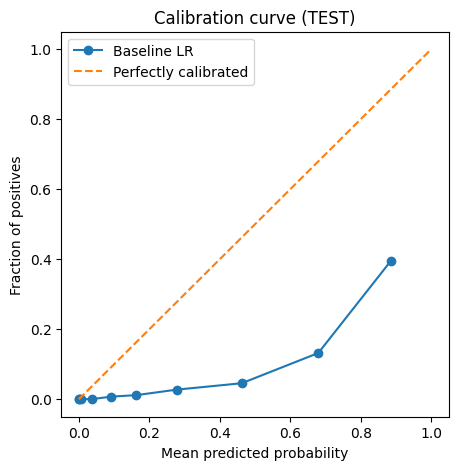

Calibrated Brier (TEST): 0.04197730247256683
Calibrated LR (TEST): {'roc_auc': 0.9229557393995562, 'pr_auc': 0.46466194967052965, 'base_rate': 0.062046844197935117}


,K_frac,K_pct,precision@K,recall@K,lift@K,n_targeted
0,0.01,1%,0.703333,0.113624,11.335521,300
1,0.05,5%,0.519706,0.418955,8.376028,1497
2,0.10,10%,0.393919,0.634895,6.348738,2993
3,0.20,20%,0.264283,0.851912,4.259416,5986


In [ ]:

# 7) Calibration: reliability curve + Brier score + isotonic calibration


from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Baseline calibration on TEST
prob_true, prob_pred = calibration_curve(y_test, test_score, n_bins=10, strategy='quantile')
print("Baseline Brier (TEST):", brier_score_loss(y_test, test_score))

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='o', label='Baseline LR')
plt.plot([0,1],[0,1],'--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curve (TEST)')
plt.legend()
plt.show()

# Calibrate using DEV only via internal CV, then evaluate on TEST
calibrated_lr = CalibratedClassifierCV(
    Pipeline(steps=[("prep", preprocess), ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))]),
    method='isotonic',
    cv=5
)
calibrated_lr.fit(X_dev, y_dev)

test_score_cal = calibrated_lr.predict_proba(X_test)[:, 1]

print("Calibrated Brier (TEST):", brier_score_loss(y_test, test_score_cal))
print("Calibrated LR (TEST):", global_metrics(y_test, test_score_cal))

display(targeting_report(y_test, test_score_cal, k_fracs=(0.01, 0.05, 0.10, 0.20)))


In [ ]:
# 8) Nonlinear benchmark model: HistGradientBoosting + OrdinalEncoder


from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

categorical_tf_ord = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess_ord = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_keep),
        ("cat", categorical_tf_ord, cat_keep),
    ],
    remainder="drop"
)

hgb = Pipeline(steps=[
    ("prep", preprocess_ord),
    ("hgb", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42
    )),
])

# Handle imbalance via sample_weight (HGB doesn't expose class_weight)
sw = compute_sample_weight(class_weight='balanced', y=y_dev)

hgb.fit(X_dev, y_dev, hgb__sample_weight=sw)

hgb_test_score = hgb.predict_proba(X_test)[:, 1]
print("HGB (TEST):", global_metrics(y_test, hgb_test_score))
display(targeting_report(y_test, hgb_test_score, k_fracs=(0.01, 0.05, 0.10, 0.20)))


HGB (TEST): {'roc_auc': 0.9294386939162362, 'pr_auc': 0.5301842974274696, 'base_rate': 0.062046844197935117}


,K_frac,K_pct,precision@K,recall@K,lift@K,n_targeted
0,0.01,1%,0.786667,0.127087,12.678593,300
1,0.05,5%,0.555778,0.448034,8.957397,1497
2,0.10,10%,0.415636,0.669898,6.698753,2993
3,0.20,20%,0.267290,0.861605,4.307880,5986


In [ ]:
# 9) Model comparison summary (baseline vs calibrated vs nonlinear)


summary = pd.DataFrame([
    {"model": "LR baseline", **global_metrics(y_test, test_score)},
    {"model": "LR calibrated (isotonic)", **global_metrics(y_test, test_score_cal)},
    {"model": "HGB (ordinal)", **global_metrics(y_test, hgb_test_score)},
])

display(summary)


,model,roc_auc,pr_auc,base_rate
0,LR baseline,0.922918,0.465915,0.062047
1,LR calibrated (isotonic),0.922956,0.464662,0.062047
2,HGB (ordinal),0.929439,0.530184,0.062047


In [108]:
# =========================
# 10) Interpretability: permutation importance on DEV
#    (avoid peeking at TEST beyond final metrics)
# =========================

from sklearn.inspection import permutation_importance

# Pick the model you want to interpret (here: hgb). You can switch to baseline_lr if preferred.
model_to_explain = hgb

perm = permutation_importance(
    model_to_explain,
    X_dev,
    y_dev,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='average_precision'
)

imp = pd.DataFrame({
    "feature": X_dev.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(imp.head(20))


,feature,importance_mean,importance_std
0,age,0.223980,0.001944
4,education,0.207795,0.002526
9,weeks_bin,0.172012,0.003956
6,major occupation code,0.130965,0.002021
1,num persons worked for employer,0.074788,0.002471
7,major industry code,0.054831,0.000724
5,class of worker,0.035401,0.001058
3,veterans benefits,0.019436,0.001942
8,marital stat,0.015090,0.001863
2,own business or self employed,0.004012,0.000276


In [109]:
# =========================
# 11) Audit by group (since fairness-sensitive vars are allowed)
#    Example: Precision@Top10% by sex / race
# =========================

def precision_at_k_series(y_true: pd.Series, y_score: pd.Series, k_frac=0.10) -> float:
    k = int(np.ceil(len(y_true) * k_frac))
    idx = np.argsort(-y_score.values)[:k]
    return float(y_true.iloc[idx].mean())

def group_precision_at_k(df_raw, group_col: str, model, k_frac=0.10):
    # df_raw must contain group_col and the model features (num_keep + cat_keep).
    out = []
    for g, dfg in df_raw.dropna(subset=[group_col]).groupby(group_col):
        Xg = dfg[num_keep + cat_keep]
        yg = dfg["y"].astype(int)
        sg = model.predict_proba(Xg)[:, 1]
        out.append({
            "group": g,
            "n": len(dfg),
            "base_rate": float(yg.mean()),
            f"precision@{int(k_frac*100)}%": precision_at_k_series(yg.reset_index(drop=True), pd.Series(sg), k_frac),
        })
    return pd.DataFrame(out).sort_values("n", ascending=False)

# Build a TEST-only DF aligned with X/y + keep raw group columns
# NOTE: train_test_split preserves indices so we can subset by X_test.index
audit_df = df_clean.loc[X_test.index, ["y"] + num_keep + cat_keep].copy()

# If you dropped 'sex'/'race' earlier from cat_keep, you can still audit using the raw columns from df
# as long as they align by row order. Here we assume df_clean row order matches original df.
audit_df["sex"] = df.loc[X_test.index, "sex"].values if "sex" in df.columns else np.nan
audit_df["race"] = df.loc[X_test.index, "race"].values if "race" in df.columns else np.nan

print("Audit model: HGB")
display(group_precision_at_k(audit_df, "sex", hgb, k_frac=0.10))
display(group_precision_at_k(audit_df, "race", hgb, k_frac=0.10).head(15))


Audit model: HGB


,group,n,base_rate,precision@10%
0,Female,15669,0.024762,0.178047
1,Male,14260,0.103015,0.586957


,group,n,base_rate,precision@10%
4,White,25096,0.067182,0.437450
2,Black,3078,0.024691,0.185065
1,Asian or Pacific Islander,868,0.086406,0.494253
3,Other,555,0.021622,0.160714
0,Amer Indian Aleut or Eskimo,332,0.024096,0.147059
